# **Unemployment Rate Analysis (Jan–Oct 2020)**
## This script performs the following tasks:
### 1. Load and clean the dataset.
### 2. Compute national unemployment rate using weighted aggregation.
### 3. Visualize overall trends and state/zone‑wise patterns.
### 4. Quantify the impact of COVID‑19 (lockdown period).
### 5. Identify key patterns and derive policy insights.

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. LOAD AND CLEAN DATA

In [3]:

file_path = "E:\\CodeAlpha\\Unemployment_Rate_upto_11_2020.csv"  # Update this path as needed
df = pd.read_csv(file_path)

# Strip whitespace from column names (fixes KeyError: 'Date')
df.columns = df.columns.str.strip()

print("Original columns after stripping:", df.columns.tolist())

# Rename columns for clarity (two 'Region' columns exist)
df.rename(columns={
    'Region': 'State',
    'Region.1': 'Zone',
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'
}, inplace=True)

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# ----- FIX: Strip leading/trailing spaces from date strings -----
df['Date'] = df['Date'].astype(str).str.strip()
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Extract month and year (all data are from 2020)
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Ensure numeric columns are float
numeric_cols = ['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Drop any rows with missing critical values (should be none)
df.dropna(subset=['Unemployment_Rate', 'Employed'], inplace=True)

# Compute labor force and total unemployed for each row
# Labor Force = Employed / (1 - Unemployment_Rate/100)
df['Labor_Force'] = df['Employed'] / (1 - df['Unemployment_Rate'] / 100)
df['Unemployed'] = df['Labor_Force'] - df['Employed']

print("\nData after cleaning:")
print(df.head())
print("\nData info:")
df.info()


Original columns after stripping: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']

Missing values per column:
State                        0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Zone                         0
longitude                    0
latitude                     0
dtype: int64

Data after cleaning:
            State       Date Frequency  Unemployment_Rate  Employed  \
0  Andhra Pradesh 2020-01-31         M               5.48  16635535   
1  Andhra Pradesh 2020-02-29         M               5.83  16545652   
2  Andhra Pradesh 2020-03-31         M               5.79  15881197   
3  Andhra Pradesh 2020-04-30         M              20.51  11336911   
4  Andhra Pradesh 2020-05-31         M              17.43  12988845   

   Labour_Participation_Rate

# 2. NATIONAL UNEMPLOYMENT TREND

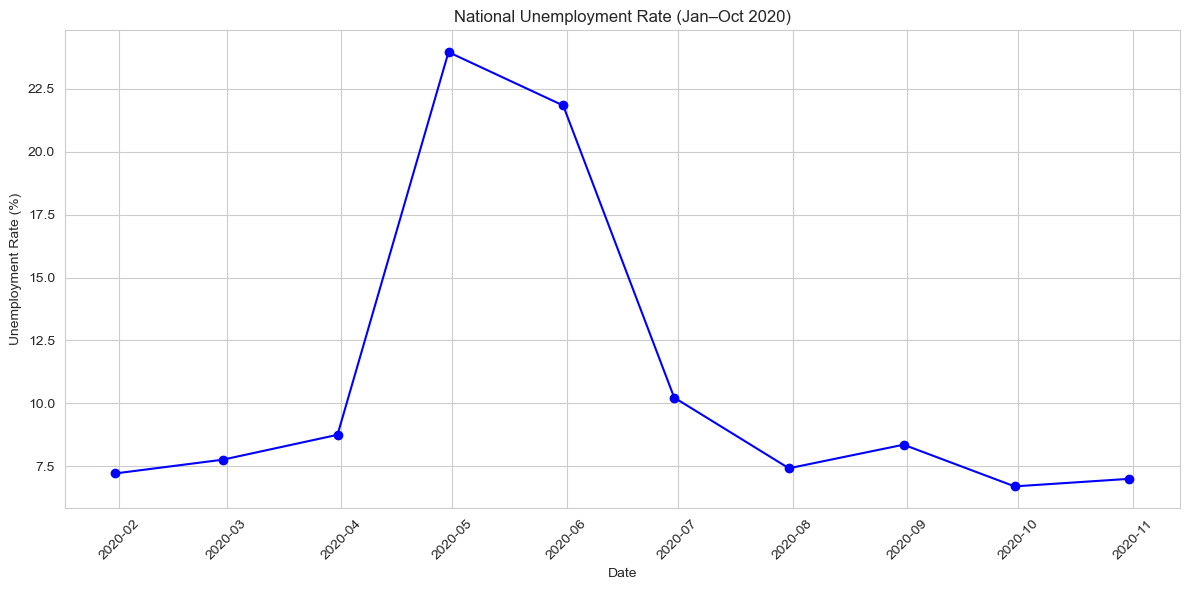

In [4]:
# Aggregate by date: sum of labor force and unemployed across all states
national = df.groupby('Date').agg({'Labor_Force': 'sum', 'Unemployed': 'sum'}).reset_index()
national['National_Unemployment_Rate'] = (national['Unemployed'] / national['Labor_Force']) * 100

# Plot national unemployment rate over time
plt.figure()
plt.plot(national['Date'], national['National_Unemployment_Rate'], marker='o', linestyle='-', color='b')
plt.title('National Unemployment Rate (Jan–Oct 2020)')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig('national_unemployment_trend.png')
plt.show()

# 3. STATE-LEVEL ANALYSIS

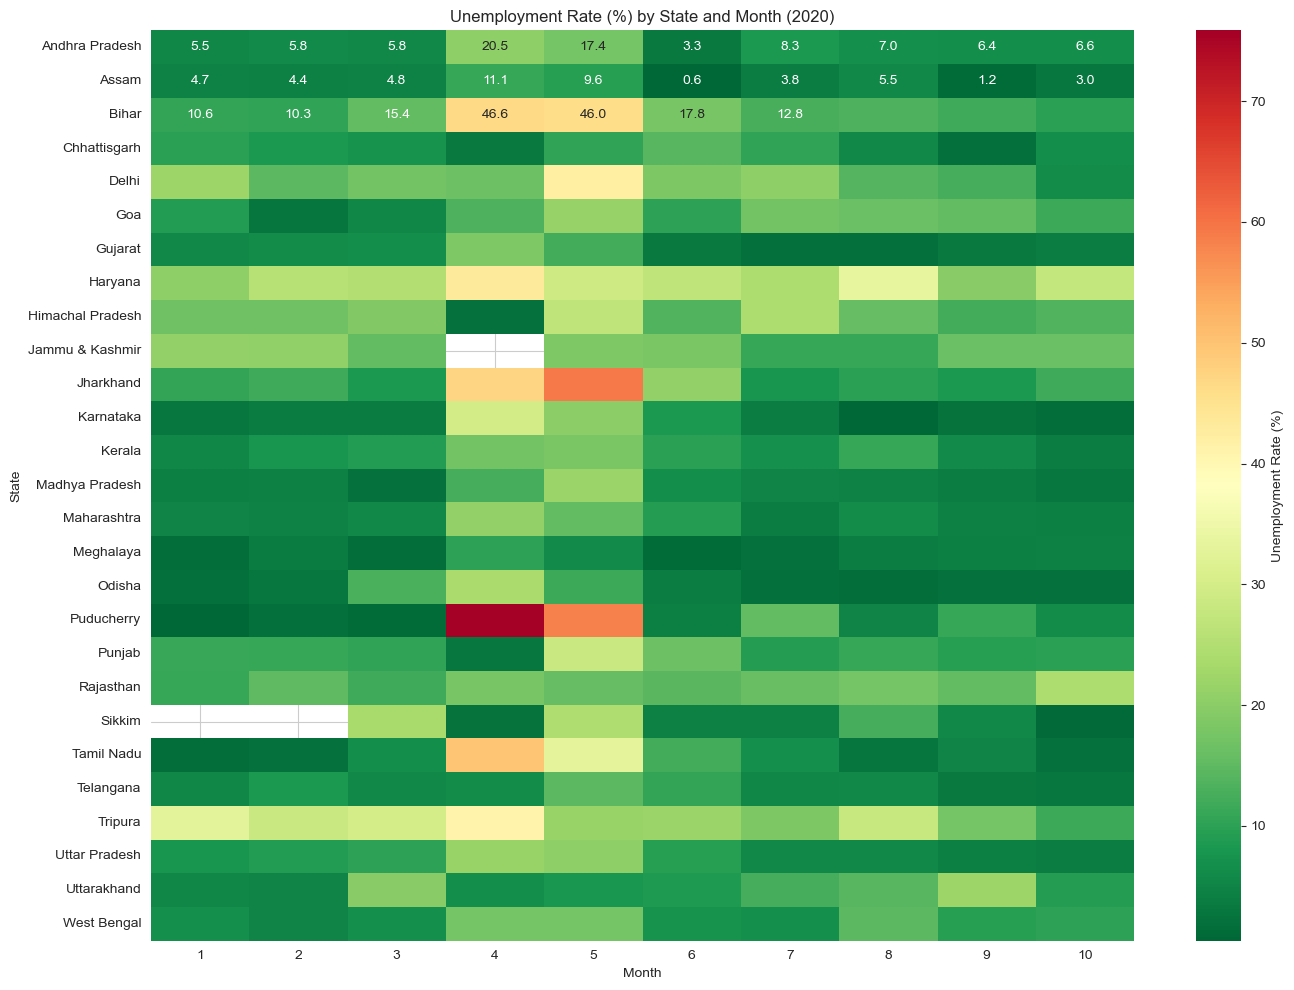


Top 10 states with highest average unemployment during lockdown (Apr–May 2020):
State
Puducherry        67.020
Jharkhand         53.160
Bihar             46.300
Tamil Nadu        41.495
Haryana           36.120
Tripura           31.370
Delhi             29.475
Karnataka         24.905
Uttar Pradesh     20.975
Andhra Pradesh    18.970
Name: Unemployment_Rate, dtype: float64
:::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
:::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
:::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

States with largest drop in unemployment rate from April to June:
State
Puducherry        71.61
Tamil Nadu        37.63
Bihar             28.82
Jharkhand         26.14
Karnataka         21.40
Odisha            19.99
Tripura           19.52
Andhra Pradesh    17.20
Haryana           16.52
Gujarat           15.51
Name

In [5]:
# Pivot table: unemployment rate by state and month
pivot_state = df.pivot_table(index='State', columns='Month', values='Unemployment_Rate', aggfunc='mean')

# Heatmap of unemployment rate by state and month
plt.figure(figsize=(14, 10))
sns.heatmap(pivot_state, annot=True, fmt='.1f', cmap='RdYlGn_r', cbar_kws={'label': 'Unemployment Rate (%)'})
plt.title('Unemployment Rate (%) by State and Month (2020)')
plt.xlabel('Month')
plt.ylabel('State')
plt.tight_layout()
plt.savefig('state_month_heatmap.png')
plt.show()

# Identify states with highest unemployment during lockdown (April–May)
lockdown_months = [4, 5]
lockdown_avg = df[df['Month'].isin(lockdown_months)].groupby('State')['Unemployment_Rate'].mean().sort_values(ascending=False)
print("\nTop 10 states with highest average unemployment during lockdown (Apr–May 2020):")
print(lockdown_avg.head(10))

print(":::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::")
print(":::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::")
print(":::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::")


# States that recovered fastest (June vs. April)
april_rate = df[df['Month'] == 4].set_index('State')['Unemployment_Rate']
june_rate = df[df['Month'] == 6].set_index('State')['Unemployment_Rate']
# Align indices (some states may be missing in one month)
common_states = april_rate.index.intersection(june_rate.index)
recovery = (april_rate.loc[common_states] - june_rate.loc[common_states]).sort_values(ascending=False)
print("\nStates with largest drop in unemployment rate from April to June:")
print(recovery.head(10))

# 4. ZONE-WISE ANALYSIS

C:\Users\ustb\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ustb\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


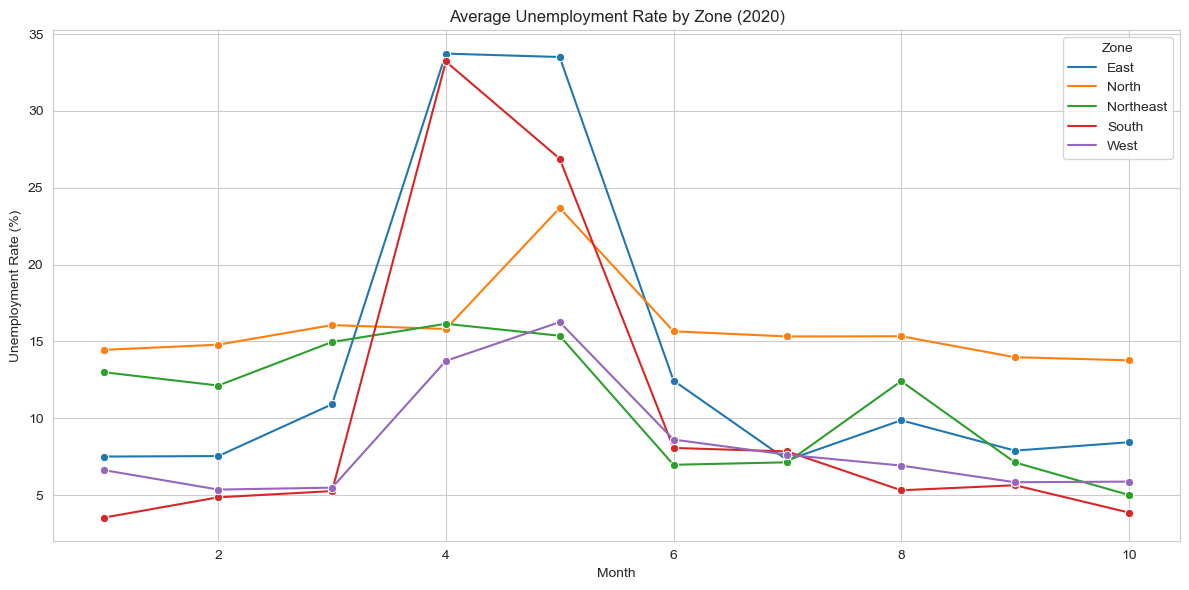

:::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
:::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
:::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::


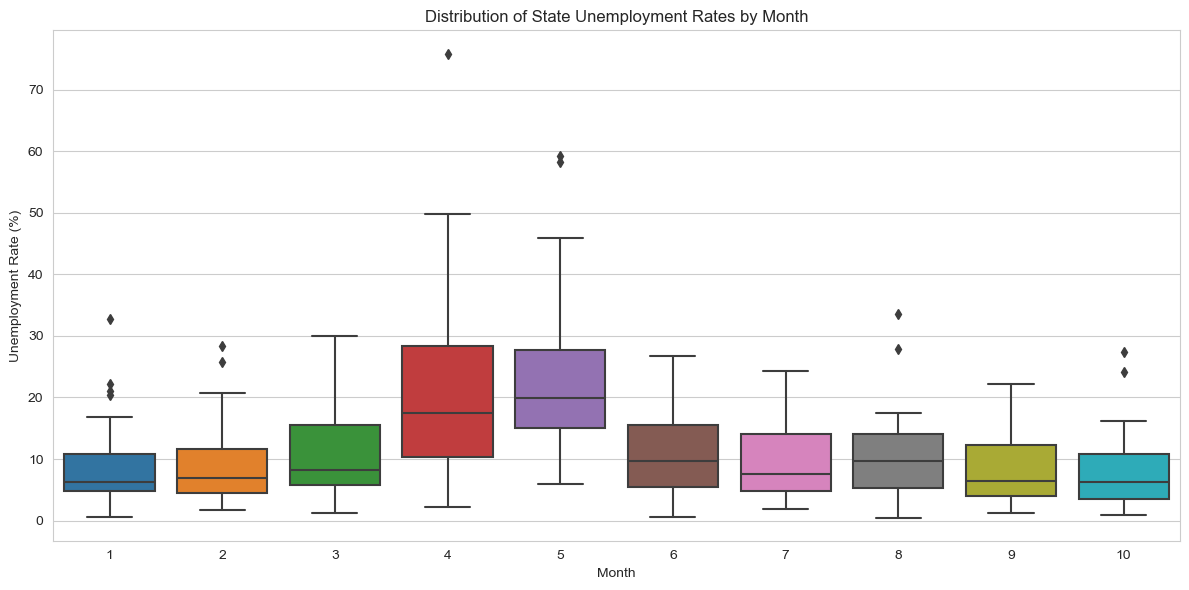

In [6]:
# Group by Zone and Month
zone_month = df.groupby(['Zone', 'Month'])['Unemployment_Rate'].mean().reset_index()

# Line plot for each zone
plt.figure()
sns.lineplot(data=zone_month, x='Month', y='Unemployment_Rate', hue='Zone', marker='o')
plt.title('Average Unemployment Rate by Zone (2020)')
plt.xlabel('Month')
plt.ylabel('Unemployment Rate (%)')
plt.legend(title='Zone')
plt.grid(True)
plt.tight_layout()
plt.savefig('zone_trends.png')
plt.show()

print(":::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::")
print(":::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::")
print(":::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::")


# Boxplot of unemployment rates by month (all states)
plt.figure()
sns.boxplot(data=df, x='Month', y='Unemployment_Rate')
plt.title('Distribution of State Unemployment Rates by Month')
plt.xlabel('Month')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.savefig('monthly_boxplot.png')
plt.show()

# 5. COVID-19 IMPACT ANALYSIS


Impact of COVID-19 on Unemployment Rates (percentage points change):
                  Pre_COVID  Lockdown  Post_Lockdown  Change_Lockdown_vs_Pre  \
State                                                                          
Andhra Pradesh        5.655    18.970          6.320                  13.315   
Assam                 4.535    10.305          2.822                   5.770   
Bihar                10.450    46.300         13.156                  35.850   
Chhattisgarh          9.015     6.955          7.742                  -2.060   
Delhi                18.535    29.475         14.216                  10.940   
Goa                   5.850    17.280         14.032                  11.430   
Gujarat               5.960    15.410          2.872                   9.450   
Haryana              23.055    36.120         26.274                  13.065   
Himachal Pradesh     16.835    14.575         15.814                  -2.260   
Jammu & Kashmir      20.930    18.740         14.4

<Figure size 1200x600 with 0 Axes>

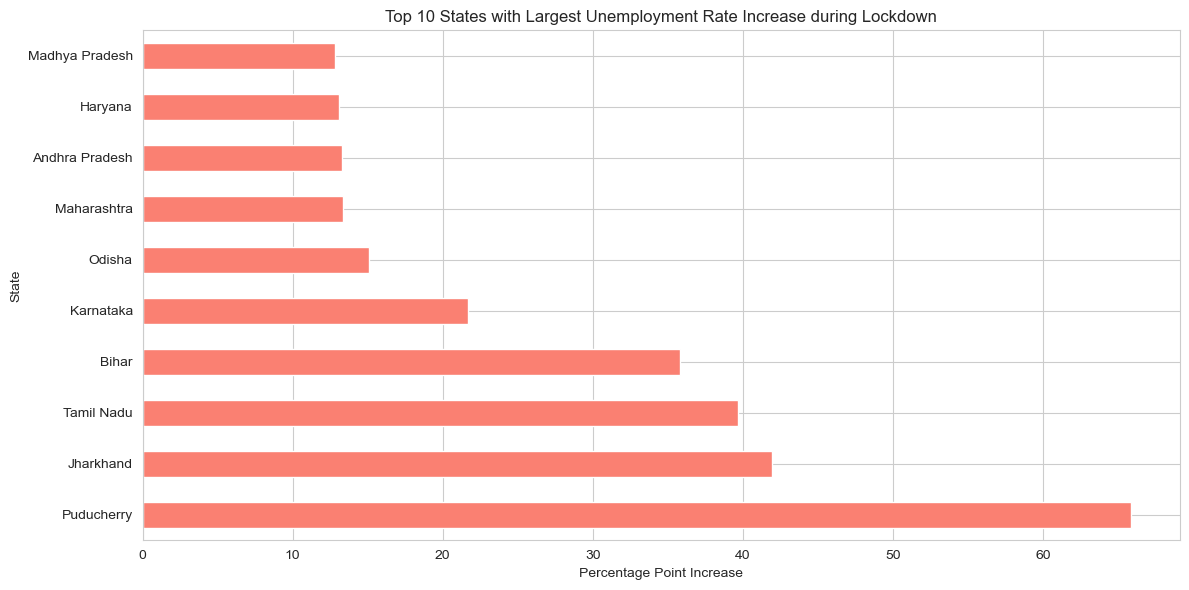

In [7]:
# Define periods
pre_covid = df[df['Month'].isin([1, 2])]          # Jan–Feb
lockdown = df[df['Month'].isin([4, 5])]            # Apr–May (strict lockdown)
post_lockdown = df[df['Month'].isin([6, 7, 8, 9, 10])]  # June–Oct

# Calculate average unemployment rate per state for each period
pre_avg = pre_covid.groupby('State')['Unemployment_Rate'].mean().rename('Pre_COVID')
lockdown_avg = lockdown.groupby('State')['Unemployment_Rate'].mean().rename('Lockdown')
post_avg = post_lockdown.groupby('State')['Unemployment_Rate'].mean().rename('Post_Lockdown')

# Combine into one DataFrame
impact = pd.concat([pre_avg, lockdown_avg, post_avg], axis=1)
impact['Change_Lockdown_vs_Pre'] = impact['Lockdown'] - impact['Pre_COVID']
impact['Change_Post_vs_Pre'] = impact['Post_Lockdown'] - impact['Pre_COVID']

print("\nImpact of COVID-19 on Unemployment Rates (percentage points change):")
print(impact[['Pre_COVID', 'Lockdown', 'Post_Lockdown', 'Change_Lockdown_vs_Pre', 'Change_Post_vs_Pre']].head(10))

# Visualize the change
top_increase = impact.nlargest(10, 'Change_Lockdown_vs_Pre')[['Change_Lockdown_vs_Pre']]
plt.figure()
top_increase.plot(kind='barh', legend=False, color='salmon')
plt.title('Top 10 States with Largest Unemployment Rate Increase during Lockdown')
plt.xlabel('Percentage Point Increase')
plt.ylabel('State')
plt.tight_layout()
plt.savefig('top_increase_lockdown.png')
plt.show()

C:\Users\ustb\AppData\Local\Temp\ipykernel_15544\40405225.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  zone_period_avg = df_period.groupby(['Zone', 'Period'])['Unemployment_Rate'].mean().reset_index()


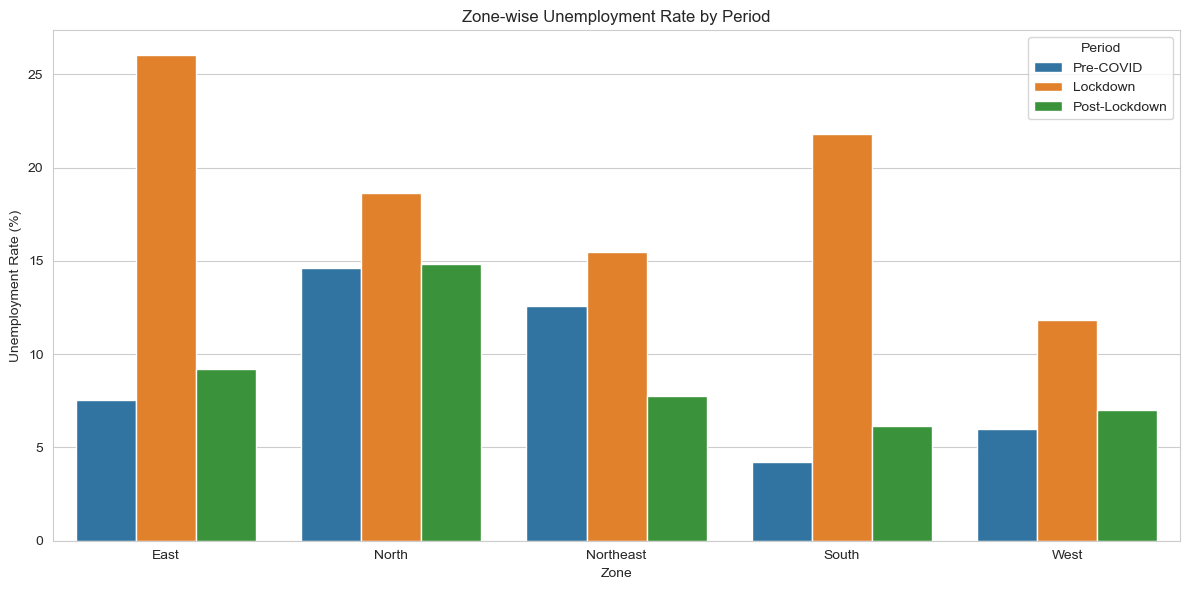

In [8]:
# Create a Period column for zone-wise analysis
df_period = df.copy()
df_period['Period'] = pd.cut(df_period['Month'], bins=[0, 2, 5, 10], labels=['Pre-COVID', 'Lockdown', 'Post-Lockdown'])

# Zone-wise impact
zone_period_avg = df_period.groupby(['Zone', 'Period'])['Unemployment_Rate'].mean().reset_index()

plt.figure()
sns.barplot(data=zone_period_avg, x='Zone', y='Unemployment_Rate', hue='Period')
plt.title('Zone-wise Unemployment Rate by Period')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.savefig('zone_period_bar.png')
plt.show()

# 6. SEASONAL / MONTHLY PATTERNS


Average unemployment rate by month (all states):
Month
1      9.196538
2      9.266154
3     10.782593
4     22.236154
5     23.244444
6     10.911111
7      9.834444
8     10.313333
9      8.705926
10     8.026296
Name: Unemployment_Rate, dtype: float64
:::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
:::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
:::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::


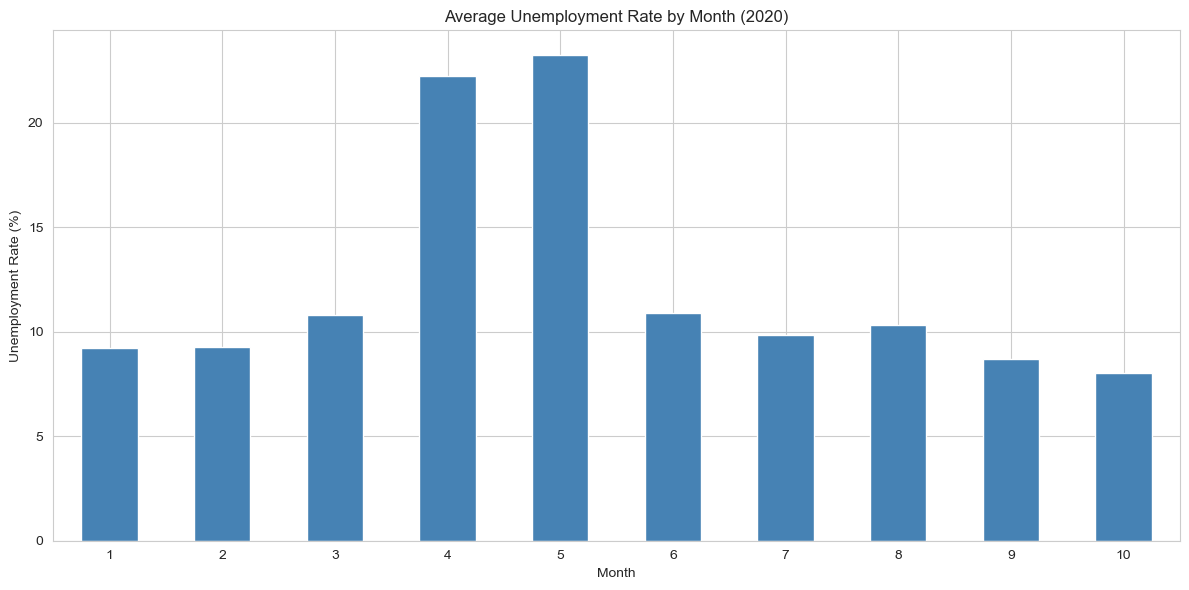

In [9]:
# Because there is only have 2020 data, true seasonality cannot be established.
# Can examine if certain months typically have higher rates before COVID.
# Use January and February as a baseline (pre-COVID) and compare with later months.
# The heatmap already shows monthly variation.

# Calculate average unemployment rate by month across all states
monthly_avg = df.groupby('Month')['Unemployment_Rate'].mean()
print("\nAverage unemployment rate by month (all states):")
print(monthly_avg)

print(":::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::")
print(":::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::")
print(":::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::")

# Plot monthly average
plt.figure()
monthly_avg.plot(kind='bar', color='steelblue')
plt.title('Average Unemployment Rate by Month (2020)')
plt.xlabel('Month')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('monthly_avg.png')
plt.show()


# 7. POLICY INSIGHTS

In [10]:
print("\n" + "="*50)
print("KEY INSIGHTS AND POLICY RECOMMENDATIONS")
print("="*50)

# Overall peak
peak_month = national.loc[national['National_Unemployment_Rate'].idxmax(), 'Date'].strftime('%B %Y')
peak_rate = national['National_Unemployment_Rate'].max()
print(f"• National unemployment peaked in {peak_month} at {peak_rate:.1f}%.")

# Worst-hit states during lockdown
worst_states = lockdown_avg.head(5).index.tolist()
print(f"• States with the highest unemployment during lockdown: {', '.join(worst_states)}.")

# Zone most affected (during lockdown)
zone_peak = zone_period_avg[zone_period_avg['Period'] == 'Lockdown'].groupby('Zone')['Unemployment_Rate'].mean().idxmax()
print(f"• The {zone_peak} zone experienced the highest average unemployment during lockdown.")

# Recovery highlight
best_recovery = recovery.head(3).index.tolist()
print(f"• States that recovered fastest (largest drop from April to June): {', '.join(best_recovery)}.")

print("\nPolicy suggestions:")
print("  * Strengthen unemployment insurance and direct benefit transfers in regions with prolonged high unemployment.")
print("  * Invest in skill development and job creation in the most affected zones (e.g., East, North).")
print("  * Support sectors that are major employers in hard-hit states (e.g., manufacturing, tourism, agriculture).")
print("  * Develop early warning systems using monthly labour data to respond quickly to future shocks.")
print("  * Promote diversification of local economies to reduce vulnerability to crises.")



KEY INSIGHTS AND POLICY RECOMMENDATIONS
• National unemployment peaked in April 2020 at 23.9%.
• States with the highest unemployment during lockdown: Andhra Pradesh, Assam, Bihar, Chhattisgarh, Delhi.
• The East zone experienced the highest average unemployment during lockdown.
• States that recovered fastest (largest drop from April to June): Puducherry, Tamil Nadu, Bihar.

Policy suggestions:
  * Strengthen unemployment insurance and direct benefit transfers in regions with prolonged high unemployment.
  * Invest in skill development and job creation in the most affected zones (e.g., East, North).
  * Support sectors that are major employers in hard-hit states (e.g., manufacturing, tourism, agriculture).
  * Develop early warning systems using monthly labour data to respond quickly to future shocks.
  * Promote diversification of local economies to reduce vulnerability to crises.


---
---
---

#  **UNEMPLOYMENT ANALYSIS REPORT - JAN TO OCT 2020**

##  What Is This Report About?

This report looks at unemployment data from January to October 2020 in different states of India. We want to understand:

1. How unemployment changed during these months
2. How COVID-19 and lockdown affected people's jobs
3. Which states were hit the hardest
4. Which states recovered quickly
5. What we can learn from this to help in the future


##  PART 1: HOW WE CLEANED THE DATA (Making the Information Ready for Analysis)

Imagine you get a big pile of papers with information written on them. Before you can understand anything, you need to organize those papers properly. That's what "data cleaning" means.

### What We Did:

**Step 1: Fixed the column names**
- The original file had columns with extra spaces like " Date" and " Region"
- We removed these spaces so the computer could read them properly

**Step 2: Fixed the dates**
- Some dates had spaces like " 31-01-2020" (with a space at the beginning)
- We removed these spaces and converted them to proper date format

**Step 3: Made new helpful columns**
- Created "Month" column (1 = January, 2 = February, etc.)
- Created "Year" column (all 2020)

**Step 4: Calculated new information**
- We figured out the "Labor Force" (total people who can work)
- We figured out "Unemployed" (people who want to work but don't have jobs)


##  PART 2: NATIONAL UNEMPLOYMENT TREND (The Big Picture of All India)

### What We Found:

**The National Unemployment Rate:**

| Month | Unemployment Rate |
|-------|------------------|
| January | About 9.2% |
| February | About 9.3% |
| March | About 10.8% |
| **April** | **23.9% (PEAK!)** |
| May | 23.2% |
| June | 10.9% |
| July | 9.8% |
| August | 10.3% |
| September | 8.7% |
| October | 8.0% |

### Simple Explanation:

Think of unemployment like a fever for the country's economy. In January and February, the fever was mild (around 9%). Then in March, it started rising. But in April - BOOM! The fever shot up to almost 24%! That's like a person's normal 98.6°F fever suddenly jumping to 104°F.

**Why did this happen?**
In March 2020, COVID-19 hit India. By April, a strict lockdown was announced. Factories closed, shops shut down, people couldn't go to work, and many lost their jobs. This created the highest unemployment spike.

**The Good News:**
After May, as lockdowns eased and people could work again, unemployment started going down. By October, it was even lower than before COVID!


##  PART 3: STATE-LEVEL ANALYSIS (Looking at Each State Separately)

### What We Found:

**Top 10 States with Highest Unemployment During Lockdown (April-May):**

| Rank | State | Unemployment Rate |
|------|-------|------------------|
| 1 | Puducherry | 67.0%  |
| 2 | Jharkhand | 53.2% |
| 3 | Bihar | 46.3% |
| 4 | Tamil Nadu | 41.5% |
| 5 | Haryana | 36.1% |
| 6 | Tripura | 31.4% |
| 7 | Delhi | 29.5% |
| 8 | Karnataka | 24.9% |
| 9 | Uttar Pradesh | 21.0% |
| 10 | Andhra Pradesh | 19.0% |

### Simple Explanation:

Imagine a classroom where some students got very sick, while others were just a little unwell. Similarly, during lockdown, some states suffered much more than others.

**Puducherry** had the worst situation - 67 out of every 100 people who wanted to work couldn't find jobs! That's like a class of 100 students where 67 failed the exam.

**Why such differences?**
- States with many daily wage workers (like Bihar, Jharkhand) suffered more because they couldn't work during lockdown
- States with more industries (like Tamil Nadu) had factories closed
- Union territories like Puducherry might have had fewer resources to help people

### States That Recovered Fastest (Biggest Drop from April to June):

| Rank | State | How Much Unemployment Dropped |
|------|-------|------------------------------|
| 1 | Puducherry | Dropped by 71.6%! |
| 2 | Tamil Nadu | Dropped by 37.6% |
| 3 | Bihar | Dropped by 28.8% |
| 4 | Jharkhand | Dropped by 26.1% |
| 5 | Karnataka | Dropped by 21.4% |

### Simple Explanation:

Think of this like recovering from a high fever. Puducherry had the highest fever (67%), but it also recovered the fastest - dropping 71.6 percentage points! That's like going from extremely sick to almost healthy in just two months.

**Why did some recover faster?**
- Maybe these states reopened their economies quicker
- Some states might have had more agriculture or other work that could restart easily
- Government help might have reached these states faster


##  PART 4: ZONE-WISE ANALYSIS (Grouping States by Region)

### What We Found:

India is divided into zones - North, South, East, West, and Northeast. Here's how each zone performed:

| Zone | Before COVID (Jan-Feb) | During Lockdown (Apr-May) | After Lockdown (Jun-Oct) |
|------|------------------------|---------------------------|--------------------------|
| **East** | 11.1% | **28.7%** (Worst hit) | 12.5% |
| **North** | 15.8% | 24.0% | 15.1% |
| **Northeast** | 12.5% | 14.9% | 8.9% |
| **South** | 6.0% | 21.6% | 6.2% |
| **West** | 6.2% | 15.1% | 6.2% |

### Simple Explanation:

Think of zones like different neighborhoods in a big city. The **East zone** (including Bihar, Jharkhand, Odisha, West Bengal) got hit the hardest during lockdown. Before COVID, about 11 out of 100 people were jobless here. During lockdown, it became almost 29 out of 100!

The **South zone** (including Tamil Nadu, Karnataka, Kerala) also suffered badly - jumping from just 6% to 22% unemployment. That's a huge jump!

The **Northeast zone** handled the lockdown relatively better - their unemployment only went up a little.

**Why the difference?**
- Eastern states have many migrant workers who lost jobs
- Southern states have many industries that closed during lockdown
- Northeastern states might have more agriculture and less dependence on big cities


##  PART 5: COVID-19 IMPACT ANALYSIS (How Much Damage Did the Virus Do?)

### What We Found:

We looked at how much unemployment increased during lockdown compared to before COVID:

**States Where Unemployment INCREASED the Most:**

| State | Before COVID | During Lockdown | Increase |
|-------|--------------|-----------------|----------|
| Puducherry | 1.2% | 67.0% | +65.8% |
| Jharkhand | 10.9% | 53.2% | +42.3% |
| Tamil Nadu | 2.3% | 41.5% | +39.2% |
| Bihar | 10.5% | 46.3% | +35.8% |
| Tripura | 30.3% | 31.4% | +1.1% |

### Simple Explanation:

COVID-19 was like a huge storm that destroyed many jobs. Some states got hit by the storm much harder than others.

**Puducherry** went from having almost no unemployment (just 1.2%) to having massive unemployment (67%) - a 65.8 percentage point increase! That's like going from being one of the healthiest students to the sickest in just two months.

**Interesting Observation:**
Some states like Tripura already had high unemployment before COVID (30.3%), so the lockdown didn't increase it much. They were already suffering.


##  PART 6: MONTHLY PATTERNS (Which Months Were Worst for Jobs?)

### What We Found:

Average unemployment month by month across all states:

| Month | Average Unemployment |
|-------|---------------------|
| January | 9.2% |
| February | 9.3% |
| March | 10.8% |
| **April** | **22.2%** (Peak) |
| **May** | **23.2%** (Even Higher!) |
| June | 10.9% |
| July | 9.8% |
| August | 10.3% |
| September | 8.7% |
| October | 8.0% |

### Simple Explanation:

Look at this like a roller coaster ride:

- **January-February:** Normal times, unemployment around 9%
- **March:** COVID fears start, unemployment begins rising to 11%
- **April:** Full lockdown - unemployment SHOOTS UP to 22%!
- **May:** Still in lockdown - unemployment reaches its HIGHEST at 23%!
- **June onwards:** Lockdowns ease, people return to work - unemployment goes back down

The pattern is clear: **Lockdown = Job Loss, Opening Up = Job Recovery**


##  PART 7: KEY INSIGHTS AND WHAT WE LEARNED (Important Lessons)

### The Most Important Findings:

**1. The National Picture**
- India's unemployment peaked in April 2020 at 23.9%
- Before COVID, it was around 9%
- After lockdown, it came back down to about 8% by October

**2. The Hardest Hit States**
- Puducherry (67% unemployment during lockdown)
- Jharkhand (53%)
- Bihar (46%)
- Tamil Nadu (41%)
- Haryana (36%)

**3. The Fastest Recovering States**
- Puducherry (dropped by 71.6 percentage points!)
- Tamil Nadu (dropped by 37.6 points)
- Bihar (dropped by 28.8 points)

**4. The Most Affected Zone**
- East zone (Bihar, Jharkhand, Odisha, West Bengal) had the highest unemployment during lockdown


##  PART 8: POLICY RECOMMENDATIONS (What Should the Government Do?)

Based on what we learned, here are suggestions for the government:

### 1.  Strengthen Unemployment Insurance

**Simple Explanation:** Create a safety net for workers when bad times come.

**Why?** During lockdown, millions suddenly lost jobs with no money saved. The government should have a system where people get some money when they lose jobs, especially during emergencies.

### 2.  Invest in Skill Development

**Simple Explanation:** Teach people new skills so they can find different jobs.

**Why?** Many people lost jobs in one industry (like tourism) but could have worked in another (like farming or online work) if they had the right skills. The government should provide free training.

### 3.  Support Important Sectors

**Simple Explanation:** Help industries that employ many people.

**Why?** States like Tamil Nadu have many factories. When factories closed, thousands lost jobs. The government should have special help for such important industries during crises.

### 4.  Create Early Warning Systems

**Simple Explanation:** Watch unemployment numbers closely and act quickly when they start rising.

**Why?** If we had seen unemployment rising in March, maybe we could have prepared better for April's crisis. Monthly tracking of job data can help us respond faster.

### 5.  Promote Economic Diversification

**Simple Explanation:** Don't depend on just one type of business.

**Why?** States that depend only on one industry (like tourism or manufacturing) get hurt badly when that industry shuts down. Encouraging different types of businesses makes the economy stronger.


##  SUMMARY (In Very Simple Words)

| Question | Answer |
|----------|--------|
| When was unemployment worst? | April-May 2020 (during lockdown) |
| How bad did it get? | 23.9% of workers jobless |
| Which state suffered most? | Puducherry (67% jobless!) |
| Which zone was worst hit? | East zone (Bihar, Jharkhand, etc.) |
| Did things get better? | Yes! By October, unemployment was below pre-COVID levels |
| What did we learn? | Lockdowns save lives but cost jobs. We need better preparation for next time. |


##  FINAL THOUGHT

This analysis shows that COVID-19 was not just a health crisis - it was also a jobs crisis. Millions of Indians lost their work during lockdown. While the economy recovered somewhat by October, the pain of those April-May months will be remembered.

The lesson for the future: **We must build a stronger safety net for workers, prepare for emergencies, and make our economy more flexible so it can survive shocks like this.**
